Install required libraries

In [2]:
!pip install torch-geometric -q
!pip install torch-scatter torch-sparse \
    -f https://data.pyg.org/whl/torch-2.0.0+cu118.html -q
!pip install rdkit -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 23.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 17.7 MB/s eta 0:00:00


Construct the GNN class

In [3]:
%%writefile /content/drive/MyDrive/DataScience/molecular-ai-agent/src/models/gnn.py

import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

class MolecularGNN(nn.Module):
    """
    Graph Neural Network of molecular property prediction.

    Architecture:
        Input: atom feature matrix (node features) + bond conntectivity
        Hidden: 4 rounds of message passing between atoms
        Output: single scalar (predicted HOLO-LUMO gap)
    How message passing works:
        Each atom collects feature vectors from its neighbors,
        average them, each atom 'knows' about atom upto 4 bonds away.
        Then we average all atom representations to get a single
        molecule-level vector.
    """

    def __init__ (
            self,
            node_features: int = 11, # size of each atom feature vector
            hidden_dim: int = 128,  # size of internal representations
            num_layers: int  = 4, # rounds of message passing
            dropout: float = 0.1
    ):
        super().__init__()

        self.num_layers = num_layers

        # Message passing layers
        # ------------------------
        # GCNConv = Graph Convolutional Network layer
        # Each layer: takes atom features -> passes messages
        # along bonds -> produces new atom features

        self.convs = nn.ModuleList()

        # fist layer: input features -> hidden_dim
        self.convs.append(GCNConv(node_features, hidden_dim))

        # remaining layers: hidden_dim -> hidden_dim
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))

        # Batch normalization
        # -------------------------
        # Normalizes activations after each layer.
        # One BN layer per GCN layer.
        self.bns = nn.ModuleList([
            nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)
        ])

        # Dropout: Randomly zeros 10%  of neurons during training.
        # ------------------------
        self.dropout = nn.Dropout(p=dropout)

        # Prediction head
        # ------------------------
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(64, 1)
        )

    def forward(self, data):
        """
        Forward pass through the GNN.

        Args:
            data: PyG Data object containing:
                data.x - atom features [num_atoms, 11]
                data.edge_index - bond connectivity [2, num_bonds*2]
                data.batch - maps atoms to their molecule index
        Returns:
            Tensor of shape [batch_size] - one prediction per molecule
        """

        x = data.x.float()          # atom features
        edge_index = data.edge_index # bond connectivity
        batch = data.batch           # which molecule each atom belongs to

        # Message passing rounds
        # ------------------------
        for conv, bn in zip(self.convs, self.bns):

            # 1. Message passing: atoms collect from neighbors
            x = conv(x, edge_index)

            # 2. Batch normalization
            x = bn(x)

            # 3. ReLU
            x = torch.relu(x)

            # 4. Dropout
            x = self.dropout(x)

        # Global pooling
        # ---------------------
        # now x shape: [total_atoms_in_batch, 128]
        # we need -> one vector per molecule, not one per atom.
        # global_mean_pool averages all atom vectors belongs to same molecule.
        # result shape: [batch_size, 128]
        x = global_mean_pool(x, batch)

        # Prediction
        return self.predictor(x).squeeze(-1)

Overwriting /content/drive/MyDrive/DataScience/molecular-ai-agent/src/models/gnn.py


Load and Split Data

In [4]:
import torch
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader

dataset = QM9(root=f'{PROJECT_DIR}/data/qm9')

torch.manual_seed(42)
dataset = dataset.shuffle()

train_dataset = dataset[:110000]
val_dataset = dataset[110000:120000]
test_dataset = dataset[120000:]

# Create data loaders
# batch_size=64 means 64 molecules processed together
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_filter` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-fitering technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


Train batches: 1719
Val batches: 157
Test batches: 169


Define model, optimizer and scheduler

In [5]:

import torch.nn as nn
from src.models.gnn import MolecularGNN
import sys

# Clear cache
mods_to_remove = [key for key in sys.modules if 'gnn' in key or 'src' in key]
for mod in mods_to_remove:
  del sys.modules[mod]

TARGET_IDX = 4 # HOMO-LUMO gap

# Conversion factor
eV_to_Hartree = 1 / 27.211

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MolecularGNN(
    node_features = 11,
    hidden_dim = 128,
    num_layers = 4,
    dropout = 0.1
).to(device)

# Adam optimizer - standard choice for GNNs
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

# reduce LR when validation stops improving
# patience = 5 means wait 5 epochs befor reducing
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience = 5,
    factor = 0.5,
    #verbose = True
)

Using device: cuda


Define train and evaluate functions

In [6]:
def train_epoch(loader):
  """Train for one epoch. Return average loss."""
  model.train()
  total_loss = 0

  for batch in loader:
    batch = batch.to(device)
    target = batch.y[:, TARGET_IDX] * eV_to_Hartree

    optimizer.zero_grad()
    pred = model(batch)
    loss = nn.MSELoss()(pred, target)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(loader)


def evaluate(loader):
  """Evaluate on val or test set. Returns MAE."""
  model.eval()
  total_mae = 0

  with torch.no_grad():
    for batch in loader:
      batch = batch.to(device)
      target = batch.y[:, TARGET_IDX] * eV_to_Hartree
      pred = model(batch)
      mae = torch.abs(pred - target).mean().item()
      total_mae += mae

  return total_mae / len(loader)

Train the model

In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs(f'{PROJECT_DIR}/models', exist_ok = True)

EPOCHS = 50
best_val_mae = float('inf')
train_losses = []
val_maes = []

print('Start training...')
print('--------------------------')

for epoch in range(1, EPOCHS + 1):

  train_loss = train_epoch(train_loader)
  val_mae = evaluate(val_loader)

  scheduler.step(val_mae)

  train_losses.append(train_loss)
  val_maes.append(val_mae)

  if val_mae < best_val_mae:
    best_val_mae = val_mae
    torch.save(
        model.state_dict(),
        f"{PROJECT_DIR}/models/best_gnn.pt"
    )
    best_marker = "<- saved"
  else:
    best_marker = ""

print(f"Training Complete.")
print(f"Best Val MAE: {best_val_mae: .5f} Hartree")


Start training...
--------------------------
Training Complete.
Best Val MAE:  0.03026 Hartree


Plot training curves

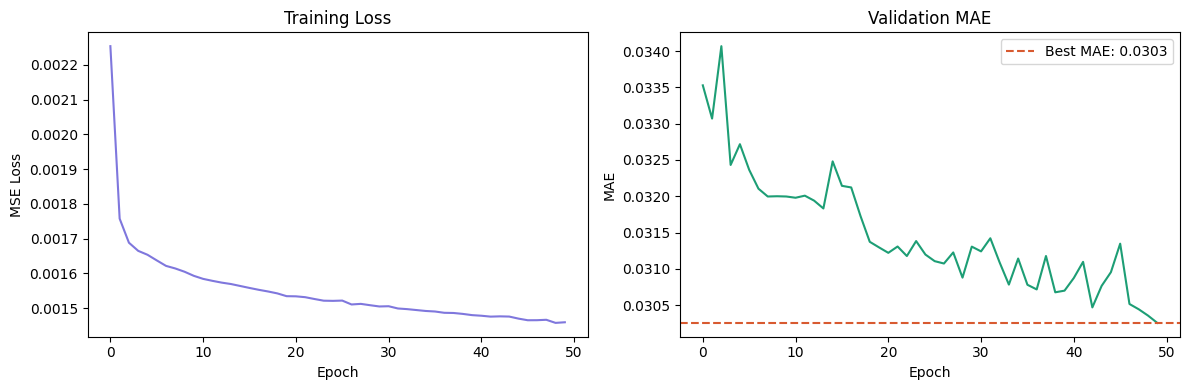

Best Val MAE : 0.0303 Hartree
Published GCN baseline: ~0.0641 Hartree


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color='#7F77DD', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss')

axes[1].plot(val_maes, color='#1D9E75', linewidth=1.5)
axes[1].axhline(y=best_val_mae, color='#D85A30', linestyle='--',
                label=f'Best MAE: {best_val_mae:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Validation MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/plots/gnn_training_curves.png', dpi=150)
plt.show()

print(f"Best Val MAE : {best_val_mae:.4f} Hartree")
print(f"Published GCN baseline: ~0.0641 Hartree")

Evaluate on test set

In [9]:
model.load_state_dict(
    torch.load(f'{PROJECT_DIR}/models/best_gnn.pt', map_location=device)
)

test_mae = evaluate(test_loader)

print(f"Test MAE          : {test_mae:.4f} Hartree")
print(f"Val MAE (best)    : {best_val_mae:.4f} Hartree")
print(f"Published baseline: ~0.0641 Hartree")

if test_mae < 0.10:
    print("Good Fit")
elif test_mae < 0.15:
    print("Consider tuning hidden_dim or epochs.")
else:
    print("Needs improvement.")

Test MAE          : 0.0306 Hartree
Val MAE (best)    : 0.0303 Hartree
Published baseline: ~0.0641 Hartree
Good Fit
